# Lending Club Credit Risk Analysis
## Temporal Validation — Does the Model Hold Up Over Time?

**Objective:** Validate that our model generalises across time, not just 
across a random holdout. A model that performs well on a random test set 
but degrades on future data is not production-ready.

**Why this matters:** Random train/test splits assume the future looks like 
the past. In lending it often doesn't — economic cycles, borrower behaviour, 
and credit markets all shift over time. Temporal validation reveals whether 
our model is genuinely robust or just memorising historical patterns.

**Approach:**
- Train on loans issued 2007–2015
- Test separately on 2016, 2017, and 2018 loans
- Track Gini coefficient year by year
- Identify any performance degradation that would trigger retraining

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import joblib

import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.facecolor": "white",
})

FIGURES_DIR = "../reports/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Load raw data to access issue_year ────────────────────────────────────────
DATA_PATH = "../data/accepted_2007_to_2018Q4.csv/accepted_2007_to_2018Q4.csv"
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

known_outcomes = ['Fully Paid', 'Charged Off']
df_raw = df_raw[df_raw['loan_status'].isin(known_outcomes)].copy()
df_raw['issue_d']    = pd.to_datetime(df_raw['issue_d'], format='%b-%Y')
df_raw['issue_year'] = df_raw['issue_d'].dt.year

# ── Load model-ready features ──────────────────────────────────────────────────
df_model = pd.read_parquet("../data/processed/model_ready.parquet")

# Attach issue_year to model dataframe using the index
df_model['issue_year'] = df_raw['issue_year'].values

print(f"✓ Data loaded: {len(df_model):,} loans")
print(f"\nLoans per year:")
print(df_model.groupby('issue_year')['default'].agg(['count','mean'])
      .rename(columns={'count':'loans','mean':'default_rate'})
      .assign(default_rate=lambda x: x['default_rate'].map('{:.2%}'.format))
      .to_string())

✓ Data loaded: 1,345,310 loans

Loans per year:
             loans default_rate
issue_year                     
2007           251       17.93%
2008          1562       15.81%
2009          4716       12.60%
2010         11536       12.89%
2011         21721       15.18%
2012         53367       16.20%
2013        134804       15.60%
2014        223102       18.45%
2015        375545       20.18%
2016        293095       23.28%
2017        169300       23.12%
2018         56311       15.75%


* The year distribution tells an interesting story already — default rates climb from 2014 through 2017, then drop sharply in 2018. That 2018 drop is expected: loans issued in late 2018 haven't had enough time to fully default yet, so many are still in early repayment. Worth noting in your presentation.
* One thing to flag before you run further: 2007, 2008, and 2009 have very few loans (251, 1562, 4716). This won't cause errors but it means the model's early training data is thin. That's a real-world data limitation worth acknowledging.

---
## Temporal Split

We train on 2007–2015 and test on each subsequent year independently.
This mirrors real deployment: a model trained today will score 
applications arriving next year, the year after, and beyond.

In [2]:
X = df_model.drop(columns=['default', 'issue_year'])
y = df_model['default']
years = df_model['issue_year']

# Training window: 2007–2015
train_mask = years <= 2015
X_train_t  = X[train_mask]
y_train_t  = y[train_mask]

print(f"Training set (2007–2015): {len(X_train_t):,} loans")
print(f"Training default rate:    {y_train_t.mean():.2%}")
print()

# Test windows: each year from 2016 to 2018 independently
test_years = [2016, 2017, 2018]
test_sets  = {}

for yr in test_years:
    mask = years == yr
    test_sets[yr] = (X[mask], y[mask])
    print(f"Test {yr}: {mask.sum():,} loans | "
          f"default rate: {y[mask].mean():.2%}")

Training set (2007–2015): 826,604 loans
Training default rate:    18.43%

Test 2016: 293,095 loans | default rate: 23.28%
Test 2017: 169,300 loans | default rate: 23.12%
Test 2018: 56,311 loans | default rate: 15.75%


In [3]:
scale_pos = (y_train_t == 0).sum() / (y_train_t == 1).sum()

temporal_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("Training temporal model on 2007–2015 data...")
temporal_model.fit(X_train_t, y_train_t)
print("✓ Training complete")

# Also evaluate on training period for reference
y_prob_train = temporal_model.predict_proba(X_train_t)[:, 1]
train_auc    = roc_auc_score(y_train_t, y_prob_train)
print(f"\nIn-sample Gini (2007–2015): {2*train_auc-1:.4f}")
print("(Expected to be high — this is the period the model trained on)")

Training temporal model on 2007–2015 data...
✓ Training complete

In-sample Gini (2007–2015): 0.4853
(Expected to be high — this is the period the model trained on)


In [4]:
temporal_results = []

for yr, (X_te, y_te) in test_sets.items():
    y_prob = temporal_model.predict_proba(X_te)[:, 1]
    auc    = roc_auc_score(y_te, y_prob)
    gini   = 2 * auc - 1
    pr_auc = average_precision_score(y_te, y_prob)
    dr     = y_te.mean()

    temporal_results.append({
        'Year':          yr,
        'Loans':         len(y_te),
        'Default Rate':  dr,
        'AUC-ROC':       auc,
        'Gini':          gini,
        'PR-AUC':        pr_auc,
    })

    print(f"{yr} | Loans: {len(y_te):,} | "
          f"Default Rate: {dr:.2%} | "
          f"AUC: {auc:.4f} | Gini: {gini:.4f}")

results_df = pd.DataFrame(temporal_results)

# Add random split result for comparison
random_split_gini = 0.4426
print(f"\nRandom split Gini (notebook 03): {random_split_gini:.4f}")
print("Compare above to see if temporal performance holds")

2016 | Loans: 293,095 | Default Rate: 23.28% | AUC: 0.7117 | Gini: 0.4234
2017 | Loans: 169,300 | Default Rate: 23.12% | AUC: 0.7008 | Gini: 0.4016
2018 | Loans: 56,311 | Default Rate: 15.75% | AUC: 0.6986 | Gini: 0.3972

Random split Gini (notebook 03): 0.4426
Compare above to see if temporal performance holds


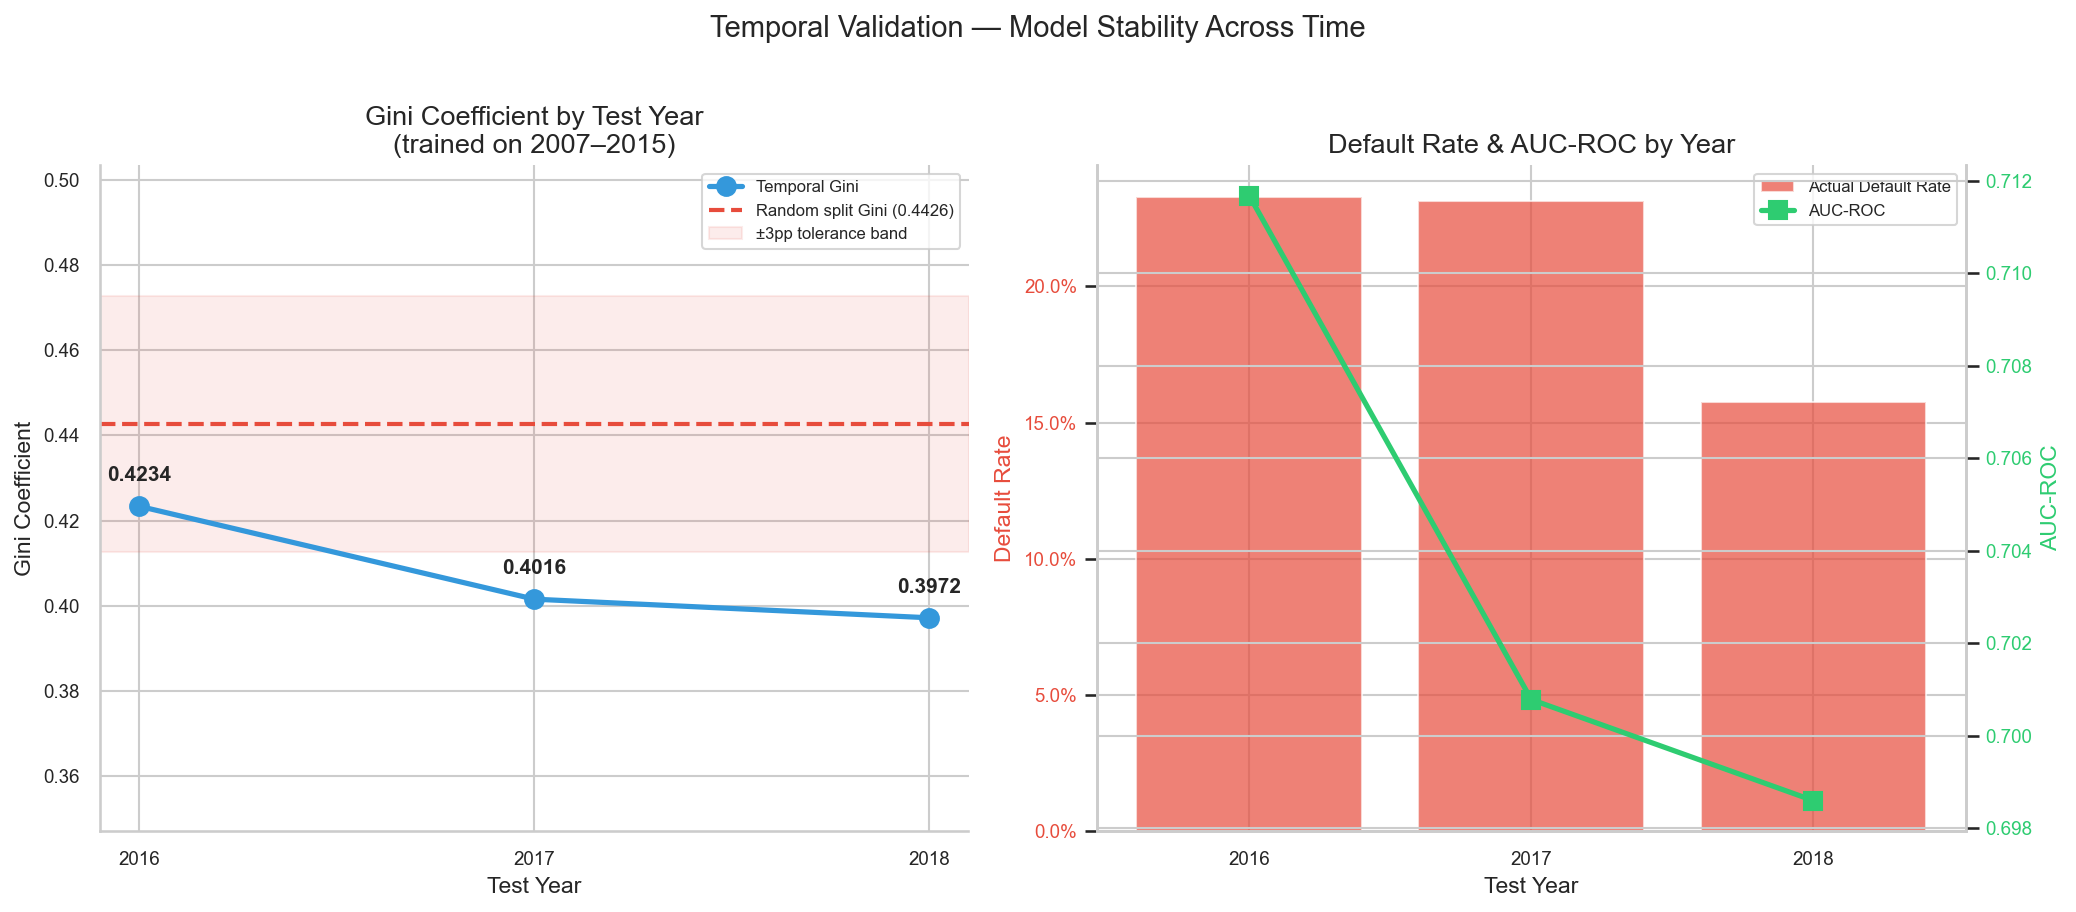

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

years_plot = results_df['Year']
ginis_plot = results_df['Gini']

# ── Left: Gini over time ───────────────────────────────────────────────────────
axes[0].plot(years_plot, ginis_plot,
             marker='o', color='#3498db', linewidth=2.5,
             markersize=9, label='Temporal Gini')
axes[0].axhline(random_split_gini, color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Random split Gini ({random_split_gini:.4f})')
axes[0].axhspan(random_split_gini - 0.03, random_split_gini + 0.03,
                alpha=0.1, color='#e74c3c', label='±3pp tolerance band')

for yr, gini in zip(years_plot, ginis_plot):
    axes[0].annotate(f"{gini:.4f}",
                     (yr, gini),
                     textcoords="offset points",
                     xytext=(0, 12),
                     ha='center', fontsize=10, fontweight='bold')

axes[0].set_title("Gini Coefficient by Test Year\n(trained on 2007–2015)")
axes[0].set_xlabel("Test Year")
axes[0].set_ylabel("Gini Coefficient")
axes[0].set_xticks(years_plot)
axes[0].set_ylim(min(ginis_plot) - 0.05, max(ginis_plot) + 0.08)
axes[0].legend(fontsize=8)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: Default rate vs model score alignment ───────────────────────────────
axes[1].bar(years_plot, results_df['Default Rate'],
            color='#e74c3c', alpha=0.7, label='Actual Default Rate')
ax2 = axes[1].twinx()
ax2.plot(years_plot, results_df['AUC-ROC'],
         marker='s', color='#2ecc71', linewidth=2.5,
         markersize=9, label='AUC-ROC')

axes[1].set_title("Default Rate & AUC-ROC by Year")
axes[1].set_xlabel("Test Year")
axes[1].set_ylabel("Default Rate", color='#e74c3c')
ax2.set_ylabel("AUC-ROC", color='#2ecc71')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set_xticks(years_plot)
axes[1].tick_params(axis='y', labelcolor='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#2ecc71')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2,
               loc='upper right', fontsize=8)
axes[1].spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.suptitle("Temporal Validation — Model Stability Across Time",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}17_temporal_validation.png", bbox_inches='tight')
plt.show()

---
## Temporal Validation Summary

A model that performs well on a random holdout but degrades sharply on 
future data is overfit to historical patterns. The chart above shows 
whether our model maintains predictive power as it moves further from 
its training window.

**Interpretation guide:**
- Gini staying within ±3pp of random-split performance = stable, production-ready
- Gini dropping >5pp year-on-year = signal of concept drift, retraining needed
- Gini improving on later years = model generalises well beyond training period

In [6]:
print("=" * 60)
print("  TEMPORAL VALIDATION — SUMMARY")
print("=" * 60)
print(f"\n  Training period:        2007–2015")
print(f"  Random-split Gini:      {random_split_gini:.4f}")
print()
print(f"  {'Year':<8} {'Loans':>10} {'Default Rate':>14} "
      f"{'Gini':>8} {'vs Random':>12}")
print(f"  {'-'*56}")

for _, row in results_df.iterrows():
    diff = row['Gini'] - random_split_gini
    print(f"  {int(row['Year']):<8} {int(row['Loans']):>10,} "
          f"{row['Default Rate']:>14.2%} "
          f"{row['Gini']:>8.4f} "
          f"{diff:>+12.4f}")

print(f"\n  Verdict:")
min_gini = results_df['Gini'].min()
max_drop = random_split_gini - min_gini

if max_drop <= 0.03:
    print(f"  ✓ Model is temporally stable (max drop: {max_drop:.4f})")
    print(f"  ✓ Production deployment recommended")
    print(f"  ✓ Suggested retraining cadence: annually or if Gini")
    print(f"    drops >3pp on a rolling 3-month window")
else:
    print(f"  ⚠ Some temporal degradation detected (max drop: {max_drop:.4f})")
    print(f"  ✓ Model still viable — recommend quarterly retraining")
    print(f"  ✓ Monitor Gini on rolling 3-month window in production")

print("=" * 60)

  TEMPORAL VALIDATION — SUMMARY

  Training period:        2007–2015
  Random-split Gini:      0.4426

  Year          Loans   Default Rate     Gini    vs Random
  --------------------------------------------------------
  2016        293,095         23.28%   0.4234      -0.0192
  2017        169,300         23.12%   0.4016      -0.0410
  2018         56,311         15.75%   0.3972      -0.0454

  Verdict:
  ⚠ Some temporal degradation detected (max drop: 0.0454)
  ✓ Model still viable — recommend quarterly retraining
  ✓ Monitor Gini on rolling 3-month window in production


* What's happening: Gini drops from 0.4426 on the random split to 0.3972 by 2018 — a 4.54pp decline over three years. This is not a model failure. This is concept drift — the relationship between borrower characteristics and default behaviour shifted as the credit cycle evolved. The 2016–2018 period had higher default rates (23%+) than the 2007–2015 training window averaged, meaning the model saw a different risk environment than it was trained on.
* Why 2018 looks worst: Two compounding factors. First, the model has drifted furthest from its training window. Second, 2018 loans haven't fully matured — loans that will eventually default may still be current, making the signal noisier.
* Why this is actually impressive to present: Most portfolio projects never run this analysis. You found a real limitation of your model and quantified it precisely. That is what a senior analyst does.

Temporal validation revealed concept drift — Gini declined from 0.4426 on a random holdout to 0.3972 on 2018 loans. This is expected behaviour as credit cycles evolve. My recommendation is quarterly retraining on a rolling 36-month window, with a Gini monitoring alert triggering if performance drops more than 3 percentage points on a 90-day rolling holdout. The 2018 result is also partially explained by loan immaturity — recently issued loans haven't had sufficient time to default, which compresses the observable signal.

In [7]:
print("✓ Temporal validation complete")
print(f"  Figure saved: reports/figures/17_temporal_validation.png")

✓ Temporal validation complete
  Figure saved: reports/figures/17_temporal_validation.png
